In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import math

In [68]:
df = pd.read_excel("Entropy_Betw_pred_FSO_RFL.xlsx")

In [69]:
df

,Predicted_FSO_Att,Predicted_RFL_Att,SYNOPCode
0,7.472554,5.516930,0
1,12.062562,12.615674,0
2,8.374322,4.015647,0
3,5.320743,11.296617,0
4,4.398330,12.456611,0
...,...,...,...
27412,7.731534,9.874434,8
27413,10.747183,10.771959,8
27414,2.925776,12.738270,8
27415,4.918909,15.006392,8


In [70]:
unique_codes = df['SYNOPCode'].unique()

# Dynamically create separate datasets as variables
for code in unique_codes:
    globals()[f"df_synop_{int(code)}"] = df[df['SYNOPCode'] == code]


In [71]:
def plot_joint_distribution(df, rf_col='Predicted_RFL_Att', fso_col='Predicted_FSO_Att', bin_width=1.0, ax=None):
    # Bin edges
    rf_bins = np.arange(df[rf_col].min(), df[rf_col].max() + bin_width, bin_width)
    fso_bins = np.arange(df[fso_col].min(), df[fso_col].max() + bin_width, bin_width)

    # Digitize
    rf_digitized = np.digitize(df[rf_col], rf_bins) - 1
    fso_digitized = np.digitize(df[fso_col], fso_bins) - 1

    # Count joint occurrences
    joint_counts = np.zeros((len(fso_bins), len(rf_bins)))
    for i, j in zip(fso_digitized, rf_digitized):
        if 0 <= i < len(fso_bins) and 0 <= j < len(rf_bins):
            joint_counts[i, j] += 1

    # Convert to probabilities
    joint_probs = joint_counts / np.sum(joint_counts)

    # Plot heatmap
    if ax is None:
        ax = plt.gca()
    im = ax.imshow(joint_probs, origin='lower', aspect='auto', cmap='viridis')
    ax.set_title(f'Bin Size = {bin_width:.1f}')
    ax.set_xlabel('RF Bins')
    ax.set_ylabel('FSO Bins')
    plt.colorbar(im, ax=ax)

    return joint_probs

In [72]:
def scan_bin_sizes_and_plot(df, rf_col='Predicted_RFL_Att', fso_col='Predicted_FSO_Att'):
    bin_sizes = np.arange(0.1, 5.1, 0.5)  # You can use 0.1 steps, but for visuals 0.5 is cleaner
    num_plots = len(bin_sizes)
    cols = 4
    rows = int(np.ceil(num_plots / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for idx, bin_size in enumerate(bin_sizes):
        plot_joint_distribution(df, rf_col, fso_col, bin_width=bin_size, ax=axes[idx])

    # Hide unused subplots if any
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

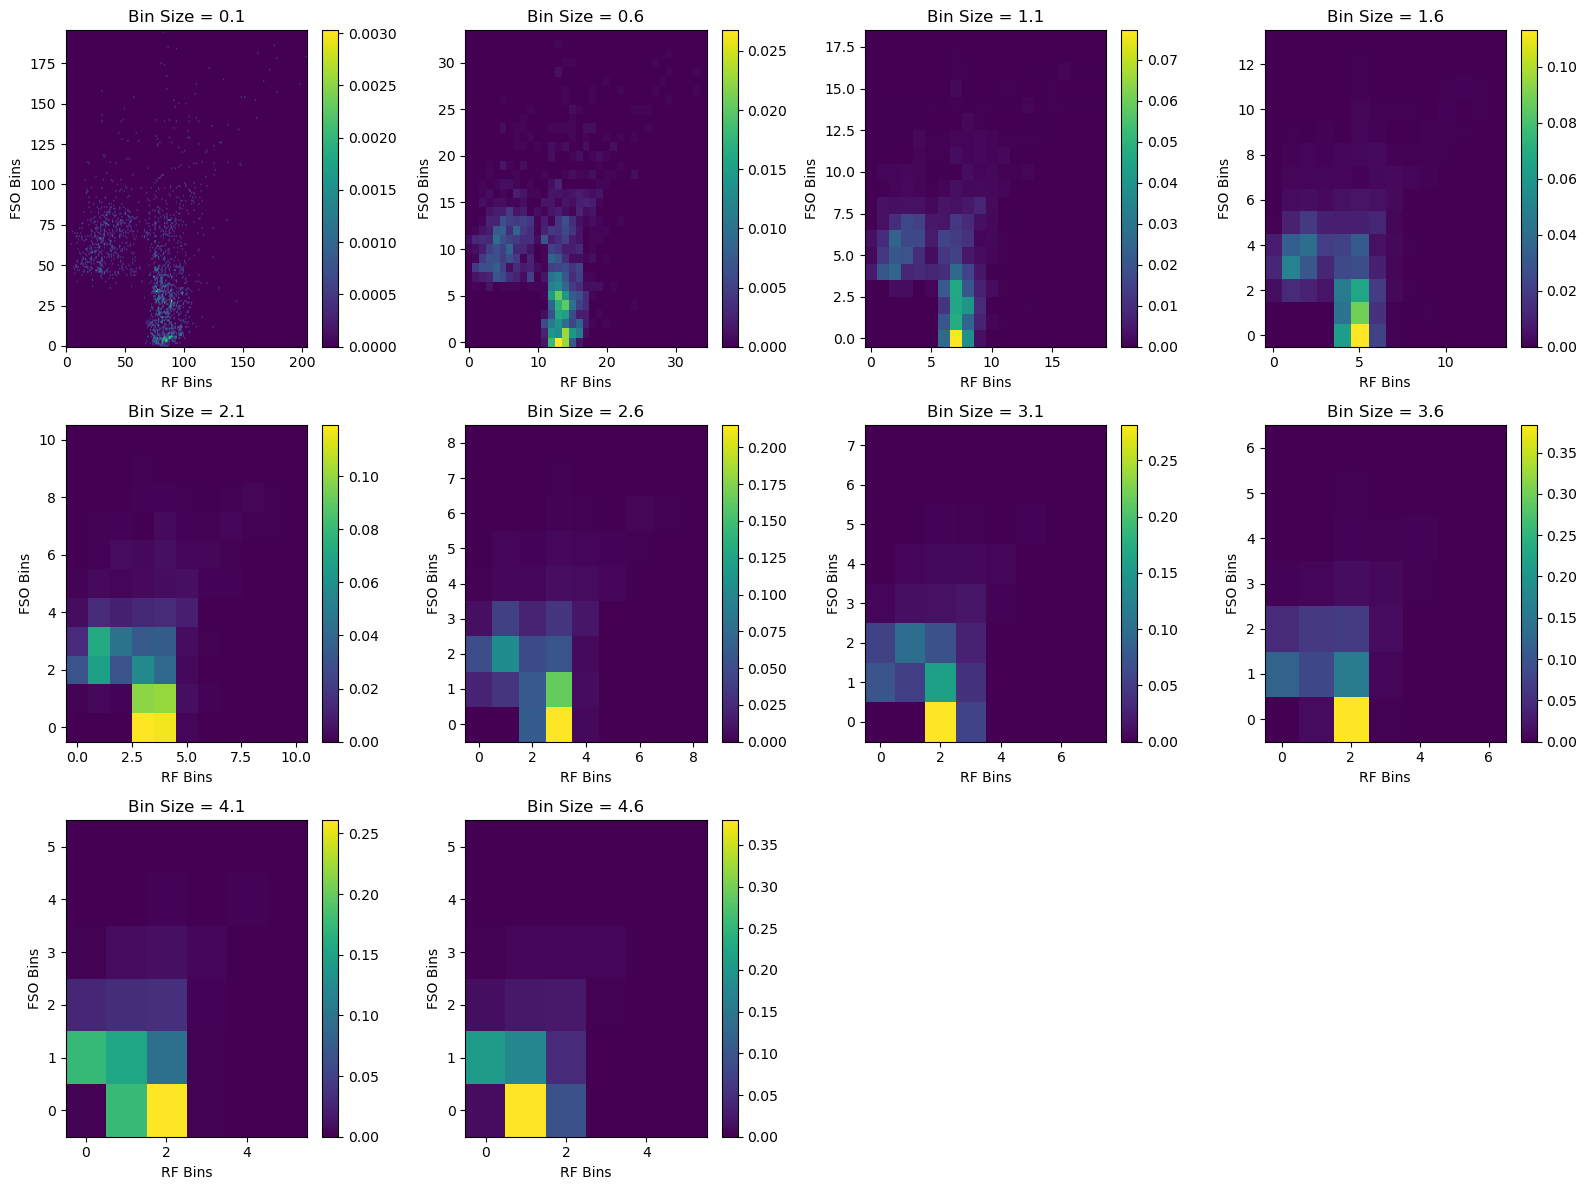

In [73]:
scan_bin_sizes_and_plot(df_synop_5)

In [74]:
# SYNOP code mapping
synop_map = {
    0: "Clear Weather",
    3: "Duststorm",
    4: "Fog",
    5: "Drizzle",
    6: "Rain",
    7: "Snow",
    8: "Showers"
}

# MI and entropy calculation
def calculate_mi_full(df_sub, bin_width = 2.1):
    rf_col = 'Predicted_RFL_Att'
    fso_col = 'Predicted_FSO_Att'

    rf_bins = np.arange(df_sub[rf_col].min(), df_sub[rf_col].max() + bin_width, bin_width)
    fso_bins = np.arange(df_sub[fso_col].min(), df_sub[fso_col].max() + bin_width, bin_width)

    rf_digitized = np.digitize(df_sub[rf_col], rf_bins) - 1
    fso_digitized = np.digitize(df_sub[fso_col], fso_bins) - 1

    joint_counts = np.zeros((len(fso_bins), len(rf_bins)))
    for i, j in zip(fso_digitized, rf_digitized):
        if 0 <= i < len(fso_bins) and 0 <= j < len(rf_bins):
            joint_counts[i, j] += 1

    joint_probs = joint_counts / np.sum(joint_counts)
    p_x = np.sum(joint_probs, axis=0)
    p_y = np.sum(joint_probs, axis=1)

    def entropy(p):
        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    H_X = entropy(p_x)
    H_Y = entropy(p_y)
    H_XY = entropy(joint_probs.flatten())
    I_XY = H_X + H_Y - H_XY

    # Normalized MIs
    NMI_X = I_XY / H_X if H_X > 0 else 0
    NMI_Y = I_XY / H_Y if H_Y > 0 else 0
    NMI_Joint = I_XY / H_XY if H_XY > 0 else 0

    # Correlation
    corr, _ = pearsonr(df_sub[rf_col], df_sub[fso_col])

    return I_XY, H_X, H_Y, H_XY, corr, NMI_X, NMI_Y, NMI_Joint

# Compute values for each weather condition
results = []
for code, label in synop_map.items():
    df_sub = df[df['SYNOPCode'] == code]
    if len(df_sub) > 10:
        mi, hx, hy, hxy, r, nmi_x, nmi_y, nmi_joint = calculate_mi_full(df_sub)
        results.append({
            'Weather': label,
            'Correlation': r,
            'MI': mi,
            'H(X)': hx,
            'H(Y)': hy,
            'H(X,Y)': hxy,
            'NMI_X': nmi_x,
            'NMI_Y': nmi_y,
            'NMI_Joint': nmi_joint
        })

result_df = pd.DataFrame(results)


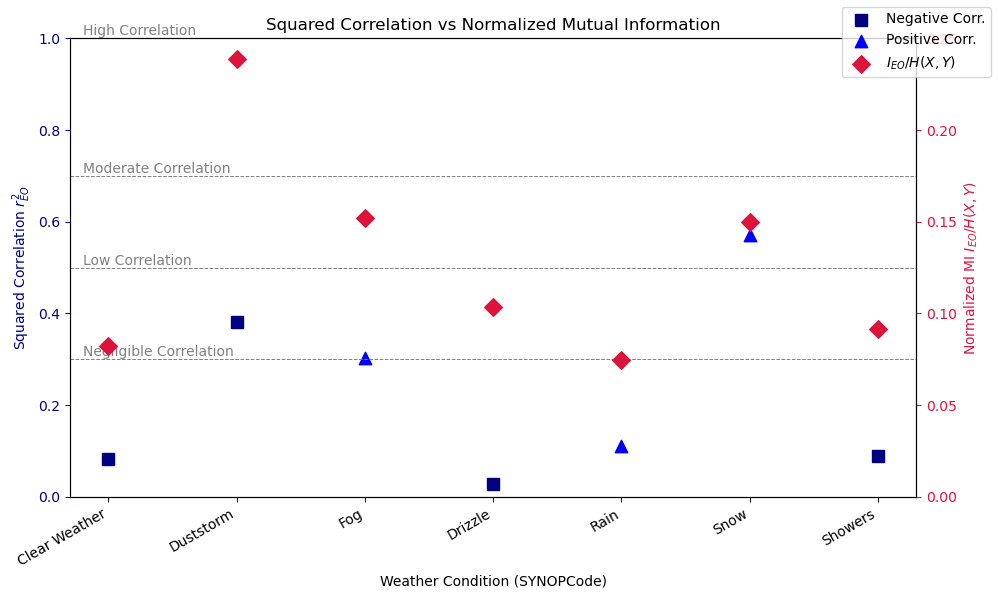

In [75]:
labels = result_df['Weather'].tolist()
x      = list(range(len(labels)))
r      = result_df['Correlation'].values
r2     = r**2
nmi    = result_df['NMI_Joint'].values

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# 1) squared‐threshold bands
thresholds = {
    "High Correlation":       1.0,
    "Moderate Correlation":   0.7,
    "Low Correlation":        0.5,
    "Negligible Correlation": 0.3
}
for txt, yval in thresholds.items():
    ax1.axhline(y=yval, color='gray', linestyle='--', linewidth=0.7)
    ax1.text(-0.2, yval, txt, va='bottom', ha='left', color='gray')

# 2) negative‐r as squares (■)
neg_mask = r < 0
ax1.scatter(
    [i for i,m in enumerate(neg_mask) if m],
    r2[neg_mask],
    marker='s', s=80, color='navy',
    label='Negative Corr.'
)

# 3) positive‐r as triangles (▲)
pos_mask = ~neg_mask
ax1.scatter(
    [i for i,m in enumerate(pos_mask) if m],
    r2[pos_mask],
    marker='^', s=80, color='blue',
    label='Positive Corr.'
)

ax1.set_ylabel(r'Squared Correlation $r^2_{EO}$', color='navy')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', colors='navy')

# 4) NMI as diamonds (♦)
ax2.scatter(
    x, nmi,
    marker='D', s=80, color='crimson',
    label=r'$I_{EO}/H(X,Y)$'
)
ax2.set_ylabel(r'Normalized MI $I_{EO}/H(X,Y)$', color='crimson')
ax2.set_ylim(0, 0.25)
ax2.tick_params(axis='y', colors='crimson')

# 5) X‐axis
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha='right')
ax1.set_xlabel('Weather Condition (SYNOPCode)')
ax1.set_title('Squared Correlation vs Normalized Mutual Information')

# 6) Legend
fig.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [76]:
result_df

,Weather,Correlation,MI,H(X),H(Y),"H(X,Y)",NMI_X,NMI_Y,NMI_Joint
0,Clear Weather,-0.286102,0.322016,1.730342,2.496145,3.904471,0.186100,0.129005,0.082474
1,Duststorm,-0.617052,0.887081,1.527721,3.076737,3.717378,0.580656,0.288319,0.238631
2,Fog,0.550923,0.528778,1.591483,2.409812,3.472517,0.332255,0.219427,0.152275
3,Drizzle,-0.167908,0.447492,2.271196,2.497421,4.321125,0.197029,0.179182,0.103559
4,Rain,0.334165,0.381523,2.726748,2.776132,5.121358,0.139918,0.137430,0.074496
5,Snow,0.755064,0.461792,0.725642,2.813565,3.077415,0.636391,0.164130,0.150058
6,Showers,-0.300429,0.410119,2.319647,2.565015,4.474543,0.176802,0.159889,0.091656
